# PHQ-8 Depression Detection — HuBERT + Bidirectional LSTM (Classification)

**Architecture**: Frozen HuBERT (`facebook/hubert-base-ls960`) → sequence of mean-pooled 768-dim segment features → `BiLSTM` → mean-pool over time → `Dropout` → `Linear(2·hidden, 1)` → binary logit.

**Task**: Binary classification — depressed (PHQ-8 ≥ 10) vs. control (PHQ-8 < 10).

**Participant-level evaluation**: Every participant's segments are fed as an ordered sequence. One logit is produced per participant per forward pass. Accuracy/loss are computed at the participant level — the model cannot overfit individual segment noise.

**Input**: Ordered sequence of 768-dim HuBERT features, one per 8-second window (4-second hop, 50% overlap).

**Target**: Binary label — 0 (control) or 1 (depressed).

**Features**: Extracted and cached to `processed/hubert_features_cls.npz` on first run.

## 1. Install Dependencies

In [47]:
!pip install transformers librosa tqdm pandas numpy scikit-learn --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [48]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Imports successful.")

Imports successful.


In [49]:
# --- Paths ---
BASE_DIR      = Path("..")
DATASET_DIR   = BASE_DIR / "dataset"
PROCESSED_DIR = BASE_DIR / "processed"

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

FEATURE_CACHE = PROCESSED_DIR / "hubert_features_cls.npz"

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "hubert_bilstm_cls"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {DEVICE}")
print(f"Feature cache  : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir : {SAVE_DIR.resolve()}")

Using device   : cuda
Feature cache  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\hubert_features_cls.npz
Checkpoint dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\hubert_bilstm_cls


## 3. Load Label Files

Binary labels:
- `PHQ8_Binary` in train/dev CSVs — 1 if PHQ-8 ≥ 10, else 0
- `PHQ_Binary` in test CSV (same threshold, different column name)

In [50]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

# pid -> binary label
train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))

pid_to_label = {**train_labels, **dev_labels, **test_labels}
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep  = sum(labels.values())
    ctrl = len(labels) - dep
    print(f"{name:5s}: {len(labels):3d} participants  "
          f"depressed: {dep}  control: {ctrl}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Feature Extraction

Audio files in `dataset/` are segmented into **8-second windows** with a **4-second (50%) hop**.
Each segment is passed through frozen HuBERT and mean-pooled over time → **768-dim feature vector**.

Features are saved to `processed/hubert_features_cls.npz` and reloaded on subsequent runs.

In [51]:
SR              = 16_000          # expected sample rate
WIN_SEC         = 8               # window length in seconds
HOP_SEC         = 4               # hop length in seconds (50% overlap)
WIN_SAMPLES     = WIN_SEC * SR    # 128,000 samples
HOP_SAMPLES     = HOP_SEC * SR    # 64,000 samples
HUBERT_MODEL_ID = "facebook/hubert-base-ls960"

if FEATURE_CACHE.exists():
    print(f"Feature cache found at {FEATURE_CACHE.name} — skipping extraction.")
else:
    print(f"Extracting HuBERT features → {FEATURE_CACHE.name}")
    print(f"  Model  : {HUBERT_MODEL_ID}")
    print(f"  Window : {WIN_SEC}s   Hop : {HOP_SEC}s")

    from transformers import HubertModel, Wav2Vec2FeatureExtractor

    feat_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL_ID)
    hubert = HubertModel.from_pretrained(HUBERT_MODEL_ID)
    hubert.eval().to(DEVICE)
    for param in hubert.parameters():
        param.requires_grad = False
    print("HuBERT loaded and frozen.")

    all_feats, all_bin_labels, all_pids, all_splits = [], [], [], []

    audio_files = sorted(DATASET_DIR.glob("*_P.wav"))
    print(f"\nProcessing {len(audio_files)} audio files ...")

    for wav_path in tqdm(audio_files):
        pid = int(wav_path.stem.split("_")[0])
        if pid not in pid_to_label:
            continue

        split = pid_to_split[pid]
        label = pid_to_label[pid]

        audio, _ = librosa.load(str(wav_path), sr=SR, mono=True)

        # Sliding-window segmentation
        starts = list(range(0, len(audio) - WIN_SAMPLES + 1, HOP_SAMPLES))
        if not starts:           # audio shorter than one window — pad
            audio  = np.pad(audio, (0, WIN_SAMPLES - len(audio)))
            starts = [0]

        for start in starts:
            seg    = audio[start : start + WIN_SAMPLES]
            inputs = feat_extractor(
                seg.tolist(), sampling_rate=SR, return_tensors="pt", padding=True
            )
            with torch.no_grad():
                hidden = hubert(
                    inputs.input_values.to(DEVICE)
                ).last_hidden_state          # (1, T, 768)
            feat = hidden.mean(dim=1).squeeze(0).cpu().numpy()  # (768,)

            all_feats.append(feat)
            all_bin_labels.append(label)
            all_pids.append(pid)
            all_splits.append(split.encode())

    np.savez_compressed(
        FEATURE_CACHE,
        feats         = np.array(all_feats,       dtype=np.float32),
        binary_labels = np.array(all_bin_labels,  dtype=np.int32),
        pids          = np.array(all_pids,         dtype=np.int32),
        splits        = np.array(all_splits),
    )
    print(f"\nSaved {len(all_feats):,} segment features → {FEATURE_CACHE}")

    # Free GPU memory used by HuBERT
    del hubert, feat_extractor
    torch.cuda.empty_cache()

Feature cache found at hubert_features_cls.npz — skipping extraction.


## 5. Build Participant-Level Dataset

Load the cached features and group segments by participant, preserving segment order.
The BiLSTM will see each participant's segments as an **ordered temporal sequence**.

In [52]:
print(f"Loading features from {FEATURE_CACHE.name} ...")
cache           = np.load(FEATURE_CACHE, allow_pickle=False)
all_feats_np    = cache["feats"]          # (N, 768)
all_labels_np   = cache["binary_labels"]  # (N,)
all_pids_np     = cache["pids"]           # (N,)
all_splits_np   = cache["splits"]         # (N,)  byte strings

# Group by participant — preserving segment order (cache stored sequentially)
in_memory = {
    "train": defaultdict(lambda: {"feats": [], "label": None}),
    "dev":   defaultdict(lambda: {"feats": [], "label": None}),
    "test":  defaultdict(lambda: {"feats": [], "label": None}),
}

for feat, lbl, pid, split_b in zip(
    all_feats_np, all_labels_np, all_pids_np, all_splits_np
):
    split = split_b.decode()
    pid   = int(pid)
    in_memory[split][pid]["feats"].append(feat)
    in_memory[split][pid]["label"] = int(lbl)

splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}

print(f"\n{'Split':10s}  {'Participants':>12}  {'Segments':>8}  {'Depressed':>9}  {'Control':>7}")
print("-" * 52)
for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
    n_segs = sum(len(d["feats"]) for _, d in splits_list[s])
    n_dep  = sum(d["label"] for _, d in splits_list[s])
    n_ctrl = len(splits_list[s]) - n_dep
    print(f"{name:10s}  {len(splits_list[s]):12d}  {n_segs:8,}  {n_dep:9d}  {n_ctrl:7d}")

Loading features from hubert_features_cls.npz ...

Split       Participants  Segments  Depressed  Control
----------------------------------------------------
train                107    11,362         30       77
validation            35     4,322         12       23
test                  47     5,904         14       33


## 6. Training Configuration

In [53]:
# --- Model hyper-parameters ---
HUBERT_DIM      = 768
LSTM_HIDDEN_DIM = 64    # per direction; BiLSTM output = 2*64 = 128
LSTM_NUM_LAYERS = 2
DROPOUT         = 0.3

# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE  = 8
NUM_EPOCHS              = 200
LEARNING_RATE           = 1e-4
WEIGHT_DECAY            = 1e-4
EARLY_STOPPING_PATIENCE = 30
CHECKPOINT_FREQ         = 10
GRAD_CLIP_NORM          = 1.0

print("Training configuration:")
print(f"  LSTM hidden dim        : {LSTM_HIDDEN_DIM}  (x2 bidirectional = {2*LSTM_HIDDEN_DIM})")
print(f"  LSTM layers            : {LSTM_NUM_LAYERS}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs patience")
print(f"  Grad clip norm         : {GRAD_CLIP_NORM}")

Training configuration:
  LSTM hidden dim        : 64  (x2 bidirectional = 128)
  LSTM layers            : 2
  Dropout                : 0.3
  Participant batch size : 8
  Epochs                 : 200
  Learning rate          : 0.0001
  Weight decay           : 0.0001
  Early stopping         : 30 epochs patience
  Grad clip norm         : 1.0


## 7. Model — HuBERT BiLSTM Classifier

```
Input  : (T, 768)   — ordered sequence of segment features for one participant
         ↓ unsqueeze(0) → (1, T, 768)
         ↓ BiLSTM(hidden=64, layers=2)  → (1, T, 128)
         ↓ mean over T                  → (1, 128)
         ↓ Dropout(0.5)
         ↓ Linear(128, 1)
Output : scalar logit  (sigmoid → probability of depression)
```

In [54]:
class HuBERTBiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM binary classifier on top of frozen HuBERT features.

    Input  : (T, 768)  — ordered sequence of segment features (one participant)
    Output : scalar logit  — positive = depressed, negative = control
    """
    def __init__(
        self,
        input_dim:  int   = HUBERT_DIM,
        hidden_dim: int   = LSTM_HIDDEN_DIM,
        num_layers: int   = LSTM_NUM_LAYERS,
        dropout:    float = DROPOUT,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = input_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2 * hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (T, 768)
        x       = x.unsqueeze(0)         # (1, T, 768)
        out, _  = self.lstm(x)           # (1, T, 2*hidden)
        pooled  = out.mean(dim=1)        # (1, 2*hidden)  — mean-pool over time
        return self.head(pooled).squeeze()   # scalar logit


model = HuBERTBiLSTMClassifier().to(DEVICE)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(10, HUBERT_DIM, device=DEVICE)   # 10 segments
    out   = model(dummy)
    print(f"Output shape (10 segments): {out.shape}  (expected: torch.Size([]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape (10 segments): torch.Size([])  (expected: torch.Size([]))
Trainable parameters: 526,465


## 8. Training Loop

**Participant-level training**: each participant's segments are fed as an ordered sequence → one logit per participant → `BCEWithLogitsLoss`.
Gradients are accumulated over `PARTICIPANT_BATCH_SIZE` participants before each optimiser step.

Accuracy is computed at the participant level: `sigmoid(logit) ≥ 0.5` → predicted depressed.

In [55]:
# ── Class-weighted loss (fixes all-control collapse) ─────────────────────────
n_dep_train  = sum(d["label"] for _, d in splits_list["train"])
n_ctrl_train = len(splits_list["train"]) - n_dep_train
pos_weight   = torch.tensor(n_ctrl_train / n_dep_train, dtype=torch.float32, device=DEVICE)
print(f"Training class counts — depressed: {n_dep_train}, control: {n_ctrl_train}")
print(f"BCEWithLogitsLoss pos_weight: {pos_weight.item():.4f}")

criterion          = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer          = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}
best_val_loss      = float("inf")
epochs_no_improve  = 0
train_participants = splits_list["train"]


def train_epoch():
    model.train()
    idx     = torch.randperm(len(train_participants)).tolist()
    batches = [
        idx[i : i + PARTICIPANT_BATCH_SIZE]
        for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)
    ]
    total_loss = 0.0
    correct    = 0
    n          = len(train_participants)

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            _, data = train_participants[i]
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit = model(feats)
            loss  = criterion(logit, label) / batch_size
            loss.backward()

            total_loss += loss.item() * batch_size
            pred        = 1 if torch.sigmoid(logit).item() >= 0.5 else 0
            correct    += int(pred == data["label"])

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return total_loss / n, correct / n


def evaluate(split: str, threshold: float = 0.5):
    """
    Participant-level evaluation.
    Returns (avg_loss, accuracy, results_df).
    """
    model.eval()
    total_loss = 0.0
    correct    = 0
    records    = []

    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit      = model(feats)
            loss       = criterion(logit, label)
            total_loss += loss.item()

            pred_prob = torch.sigmoid(logit).item()
            pred      = 1 if pred_prob >= threshold else 0
            correct  += int(pred == data["label"])
            records.append((pid, pred, pred_prob, data["label"]))

    n   = len(splits_list[split])
    df  = pd.DataFrame(records, columns=["participant_id", "pred", "pred_prob", "label"])
    return total_loss / n, correct / n, df


# ── Training ──────────────────────────────────────────────────────────────────
print(f"\nTraining on {len(train_participants)} participants for up to {NUM_EPOCHS} epochs.")
print()
print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("-" * 52)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc         = train_epoch()
    val_loss,   val_acc,   _      = evaluate("dev")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"{epoch:6d}  {train_loss:10.4f}  {train_acc:9.4f}  {val_loss:8.4f}  {val_acc:7.4f}")

    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_HuBERT_biLSTM_cls.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss":           train_loss,
            "val_loss":             val_loss,
        }, ckpt_path)

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        best_path = SAVE_DIR / "HuBERT_biLSTM_cls_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":             val_loss,
            "val_acc":              val_acc,
        }, best_path)
        print(f"  *** Best model saved  "
              f"val loss {val_loss:.4f}  val acc {val_acc:.4f} ***")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} — "
                  f"no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
best_epoch_idx = history["val_loss"].index(min(history["val_loss"]))
print(f"Best val loss     : {min(history['val_loss']):.4f}  (epoch {best_epoch_idx + 1})")
print(f"Best val accuracy : {history['val_acc'][best_epoch_idx]:.4f}")

# ── Threshold tuning on validation set ───────────────────────────────────────
best_ckpt = torch.load(
    SAVE_DIR / "HuBERT_biLSTM_cls_best.pth",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(best_ckpt["model_state_dict"])

_, _, val_df = evaluate("dev", threshold=0.5)
best_thresh, best_val_f1 = 0.5, 0.0
for thresh in np.arange(0.1, 0.91, 0.05):
    y_t = val_df["label"].values.astype(int)
    y_p = (val_df["pred_prob"].values >= thresh).astype(int)
    f1  = f1_score(y_t, y_p, average="macro", zero_division=0)
    if f1 > best_val_f1:
        best_val_f1   = f1
        best_thresh   = float(thresh)

print(f"\nThreshold tuned on validation set → {best_thresh:.2f}  (val F1 = {best_val_f1:.4f})")


Training class counts — depressed: 30, control: 77
BCEWithLogitsLoss pos_weight: 2.5667

Training on 107 participants for up to 200 epochs.

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
----------------------------------------------------
     1      0.9987     0.7196    1.0717   0.6571
  *** Best model saved  val loss 1.0717  val acc 0.6571 ***
     2      0.9996     0.7290    1.0693   0.6571
  *** Best model saved  val loss 1.0693  val acc 0.6571 ***
     3      0.9949     0.7103    1.0690   0.6571
  *** Best model saved  val loss 1.0690  val acc 0.6571 ***
     4      1.0025     0.5981    1.0670   0.6571
  *** Best model saved  val loss 1.0670  val acc 0.6571 ***
     5      0.9938     0.6916    1.0651   0.6857
  *** Best model saved  val loss 1.0651  val acc 0.6857 ***
     6      0.9947     0.5607    1.0623   0.5143
  *** Best model saved  val loss 1.0623  val acc 0.5143 ***
     7      0.9939     0.5794    1.0622   0.6000
  *** Best model saved  val loss 1.0622  val acc 0.600

## 9. Training Curves

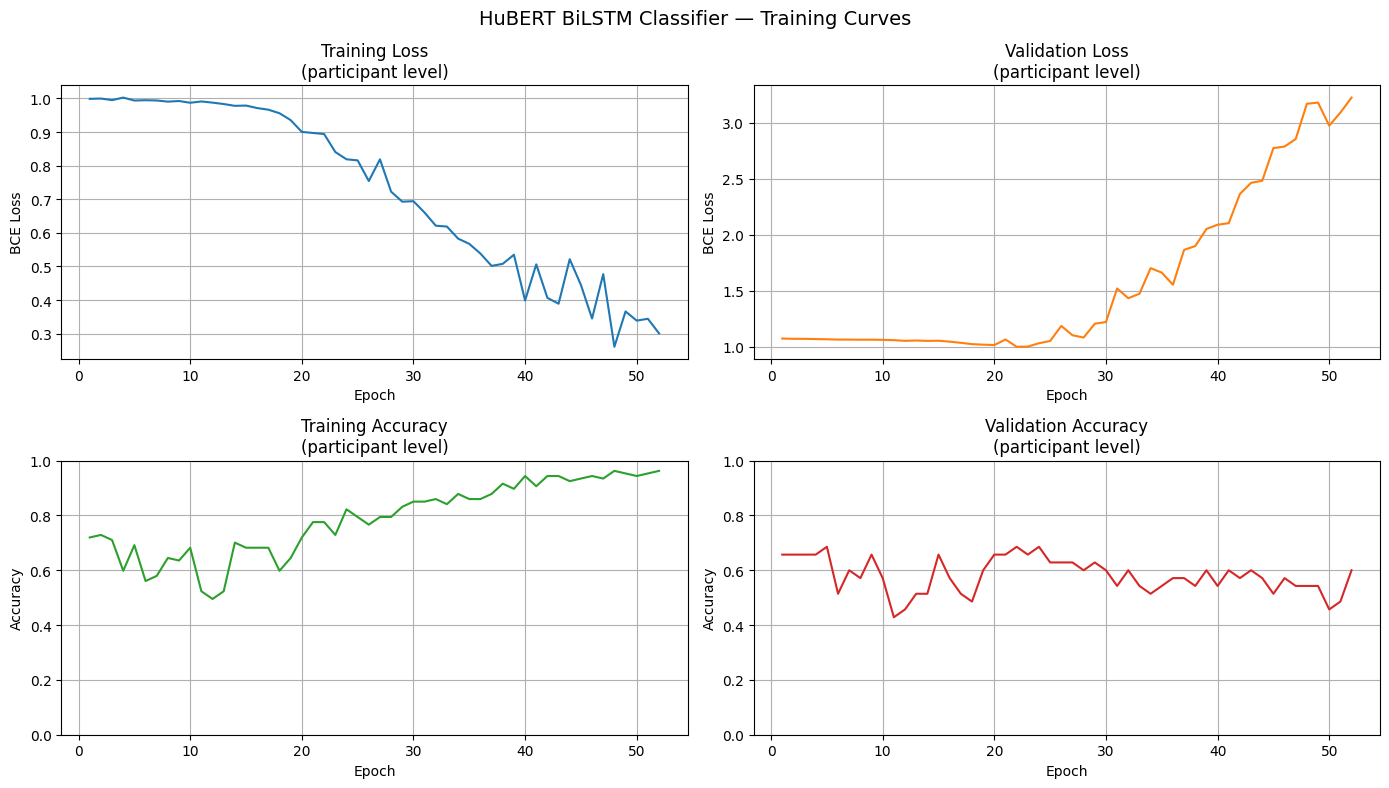

In [56]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── Loss ──────────────────────────────────────────────────────────────────────
axes[0, 0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE Loss")
axes[0, 0].set_title("Training Loss\n(participant level)")
axes[0, 0].grid(True)

axes[0, 1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("BCE Loss")
axes[0, 1].set_title("Validation Loss\n(participant level)")
axes[0, 1].grid(True)

# ── Accuracy ──────────────────────────────────────────────────────────────────
axes[1, 0].plot(epochs_ran, history["train_acc"], color="tab:green")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Training Accuracy\n(participant level)")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True)

axes[1, 1].plot(epochs_ran, history["val_acc"], color="tab:red")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Validation Accuracy\n(participant level)")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True)

plt.suptitle("HuBERT BiLSTM Classifier — Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Evaluation on Test Set

Loads the best checkpoint (lowest validation loss) and reports participant-level
**accuracy, precision, recall, and F1 score**.

In [57]:
# best_ckpt and model already loaded + threshold tuned at end of training cell
_, _, test_results_df = evaluate("test", threshold=best_thresh)

y_true = test_results_df["label"].values.astype(int)
y_pred = test_results_df["pred"].values.astype(int)

test_acc  = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, zero_division=0)
test_rec  = recall_score(y_true, y_pred, zero_division=0)
test_f1   = f1_score(y_true, y_pred, zero_division=0)

print(f"Best checkpoint : epoch {best_ckpt['epoch']}  "
      f"(val loss {best_ckpt['val_loss']:.4f}, val acc {best_ckpt['val_acc']:.4f})")
print(f"Decision threshold: {best_thresh:.2f}  (tuned on validation F1)")
print(f"\nParticipants evaluated: {len(test_results_df)}")
print()
print("── Test-set results (participant level) ──────────────────")
print(f"  Accuracy  : {test_acc:.4f}  "
      f"({int(test_acc * len(y_true))}/{len(y_true)} correct)")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Control", "Depressed"], zero_division=0))


Best checkpoint : epoch 22  (val loss 0.9982, val acc 0.6857)
Decision threshold: 0.50  (tuned on validation F1)

Participants evaluated: 47

── Test-set results (participant level) ──────────────────
  Accuracy  : 0.5957  (28/47 correct)
  Precision : 0.3333
  Recall    : 0.3571
  F1 Score  : 0.3448

              precision    recall  f1-score   support

     Control       0.72      0.70      0.71        33
   Depressed       0.33      0.36      0.34        14

    accuracy                           0.60        47
   macro avg       0.53      0.53      0.53        47
weighted avg       0.60      0.60      0.60        47



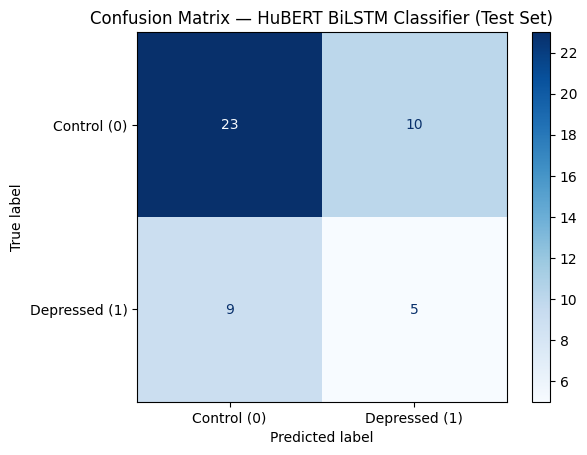

In [58]:
# plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "Depressed (1)"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — HuBERT BiLSTM Classifier (Test Set)")
plt.show()